In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px

In [55]:
air_quality_data = pd.read_csv("Combined data (Nov 2025-Apr 2026).csv")
air_quality_data.head()

,Source.Name,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,April 2026.csv,4962,pms5003,76,-1.261,36.782,01/04/2026 03:00,P2,8.0
1,April 2026.csv,4962,pms5003,76,-1.261,36.782,01/04/2026 03:00,P1,9.0
2,April 2026.csv,4962,pms5003,76,-1.261,36.782,01/04/2026 03:00,P0,5.0
3,April 2026.csv,4963,DHT22,76,-1.261,36.782,01/04/2026 03:00,humidity,97.2
4,April 2026.csv,4963,DHT22,76,-1.261,36.782,01/04/2026 03:00,temperature,18.4


In [56]:
air_quality_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 548633 entries, 0 to 548632
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Source.Name  548633 non-null  str    
 1   sensor_id    548633 non-null  int64  
 2   sensor_type  548633 non-null  str    
 3   location     548633 non-null  int64  
 4   lat          547788 non-null  float64
 5   lon          548633 non-null  float64
 6   timestamp    548633 non-null  str    
 7   value_type   548633 non-null  str    
 8   value        548551 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 37.7 MB


In [57]:
air_quality_data.timestamp = pd.to_datetime(air_quality_data.timestamp, format='%d/%m/%Y %H:%M')
air_quality_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 548633 entries, 0 to 548632
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Source.Name  548633 non-null  str           
 1   sensor_id    548633 non-null  int64         
 2   sensor_type  548633 non-null  str           
 3   location     548633 non-null  int64         
 4   lat          547788 non-null  float64       
 5   lon          548633 non-null  float64       
 6   timestamp    548633 non-null  datetime64[us]
 7   value_type   548633 non-null  str           
 8   value        548551 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 37.7 MB


In [59]:
air_quality_data.set_index('timestamp', inplace = True)

In [60]:
air_quality_data.head()

,Source.Name,sensor_id,sensor_type,location,lat,lon,value_type,value
timestamp,,,,,,,,
2026-04-01 03:00:00,April 2026.csv,4962,pms5003,76,-1.261,36.782,P2,8.0
2026-04-01 03:00:00,April 2026.csv,4962,pms5003,76,-1.261,36.782,P1,9.0
2026-04-01 03:00:00,April 2026.csv,4962,pms5003,76,-1.261,36.782,P0,5.0
2026-04-01 03:00:00,April 2026.csv,4963,DHT22,76,-1.261,36.782,humidity,97.2
2026-04-01 03:00:00,April 2026.csv,4963,DHT22,76,-1.261,36.782,temperature,18.4


In [61]:
air_quality_data = air_quality_data.sort_index()

In [62]:
grouped_aq_values = air_quality_data.groupby('value_type').resample('D')[['value']].mean().groupby(level=0).rolling(window=3).mean()
grouped_aq_values.head(20)


value
value_type value_type timestamp            
P0         P0         2025-11-01        NaN
                      2025-11-02        NaN
                      2025-11-03  16.177772
                      2025-11-04  14.917468
                      2025-11-05  14.675954
                      2025-11-06  14.326988
                      2025-11-07  12.752921
                      2025-11-08  11.085058
                      2025-11-09  10.779477
                      2025-11-10  13.264287
                      2025-11-11  15.737466
                      2025-11-12  17.276308
                      2025-11-13  15.870065
                      2025-11-14  14.601496
                      2025-11-15  13.493549
                      2025-11-16  13.235670
                      2025-11-17  12.925536
                      2025-11-18  12.970029
                      2025-11-19  12.897851
                      2025-11-20  13.398026

In [44]:
grouped_aq_values.isnull().sum()

value    163
dtype: int64

In [63]:
grouped_aq_values.dropna(inplace = True)

In [64]:
print(grouped_aq_values.columns)

Index(['value'], dtype='str')


In [66]:
grouped_aq_values.index

MultiIndex([(         'P0',          'P0', '2025-11-03'),
            (         'P0',          'P0', '2025-11-04'),
            (         'P0',          'P0', '2025-11-05'),
            (         'P0',          'P0', '2025-11-06'),
            (         'P0',          'P0', '2025-11-07'),
            (         'P0',          'P0', '2025-11-08'),
            (         'P0',          'P0', '2025-11-09'),
            (         'P0',          'P0', '2025-11-10'),
            (         'P0',          'P0', '2025-11-11'),
            (         'P0',          'P0', '2025-11-12'),
            ...
            ('temperature', 'temperature', '2026-03-26'),
            ('temperature', 'temperature', '2026-03-27'),
            ('temperature', 'temperature', '2026-03-28'),
            ('temperature', 'temperature', '2026-03-29'),
            ('temperature', 'temperature', '2026-03-30'),
            ('temperature', 'temperature', '2026-03-31'),
            ('temperature', 'temperature', '2026-04-01')

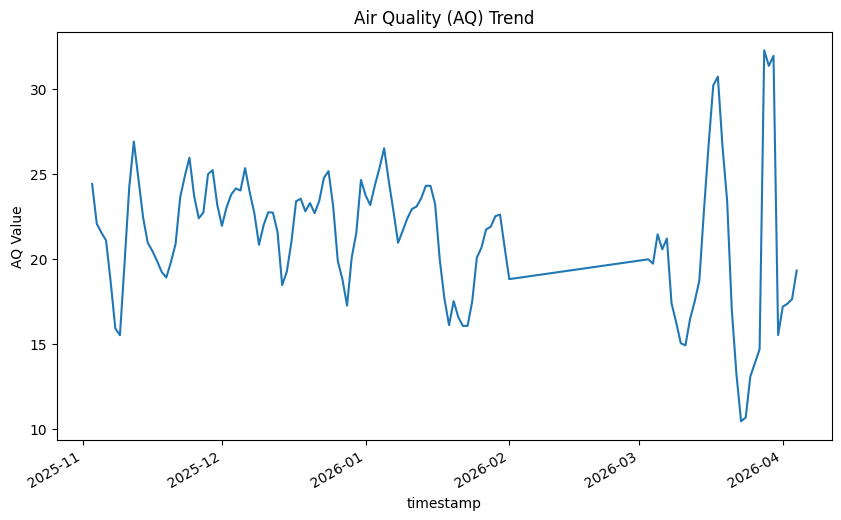

In [105]:
p2_df = grouped_aq_values.xs('P2', level=1)
p2_df = p2_df.reset_index(level=0, drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Air Quality (AQ) Trend')
ax.set_ylabel('AQ Value')
p2_df['value'].plot(ax = ax)
plt.show()